# Seismology Lab: Earthquake sources, waveforms, and focal mechanisms

> **Colab note:** This notebook is designed to run on **Google Colab**. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS166/blob/main/notebooks/05_seismology.ipynb)

## Introduction

In lecture we saw that earthquakes produce two distinct kinds of ground motion: permanent static offsets recorded by GNSS, and transient seismic waves recorded by seismometers. In this lab you will work with both. Using the 2019 Ridgecrest M7.1 earthquake as a case study, you will move from raw waveforms through seismic moment to focal mechanisms — building a complete seismological picture of a single event and connecting it to what geodesy tells us about the same earthquake.

The Ridgecrest sequence is ideal for this lab: it is recent, well-recorded, located in a well-instrumented part of California, and the fault system is geologically simple enough to interpret clearly.

## Learning objectives

By the end, you will be able to:

- distinguish static and dynamic deformation in high-rate GNSS time series
- identify P and S wave arrivals on broadband seismograms and describe how waveforms change with distance
- compute scalar seismic moment from fault parameters and convert to moment magnitude
- plot P-wave polarity observations on a focal sphere and interpret the resulting focal mechanism
- connect focal mechanism geometry to the regional tectonic setting

## Notebook outline
- [Setup](#setup)
- [Part I: Static vs. dynamic deformation from high-rate GNSS](#part-i-static-vs-dynamic-deformation-from-high-rate-gnss)
- [Part II: Seismograms and phase identification](#part-ii-seismograms-and-phase-identification)
- [Part III: Seismic moment and magnitude](#part-iii-seismic-moment-and-magnitude)
- [Part IV: First motions and focal mechanisms](#part-iv-first-motions-and-focal-mechanisms)
- [Synthesis](#synthesis)
- [Summary](#summary)


## Setup

Install and import the packages used in this lab. We use **ObsPy** to fetch and process seismic data directly from the IRIS and UNAVCO data centers, and standard scientific Python for analysis and visualization.


In [1]:
%pip install -q obspy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import PatchCollection
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Ridgecrest M7.1 event parameters
EQ_TIME   = UTCDateTime("2019-07-06T03:19:53")
EQ_LAT    = 35.770
EQ_LON    = -117.599
EQ_DEPTH  = 8.0      # km
EQ_MW     = 7.1

print("Setup complete.")
print(f"Event: Ridgecrest M{EQ_MW}, {EQ_TIME.date}, ({EQ_LAT:.3f}N, {EQ_LON:.3f}E)")


Note: you may need to restart the kernel to use updated packages.
Setup complete.
Event: Ridgecrest M7.1, 2019-07-06, (35.770N, -117.599E)


---
## Part I: Static vs. dynamic deformation from high-rate GNSS

High-rate (1 Hz) GNSS records both the passage of seismic waves and the permanent coseismic offset in a single time series. In this part you will load pre-processed 1 Hz GNSS displacement data from the Zenodo archive of Milliner & Donnellan (2020) for stations at different distances from the Ridgecrest M7.1, identify both signals, and measure the static offset.

The files are in MiniSEED format with channel codes `LYE` (east), `LYN` (north), `LYZ` (up) and a 1 Hz sample rate. Displacements are in metres.

Archived data: [Melgar et al. (2019), Zenodo](https://zenodo.org/records/3366342)  
Course copy: [datasets/Ridgecrest_GNSS_2019/](https://github.com/amtseismo/EPS166/tree/main/datasets/Ridgecrest_GNSS_2019)

### GNSS station selection

We use a subset of the nine available stations spanning a range of epicentral distances:

| Station | Approx. distance (km) | Location |
|---------|----------------------|----------|
| p595    | ~13                  | Ridgecrest, near field |
| p594    | ~20                  | Near field |
| p593    | ~30                  | Near–intermediate |
| p580    | ~50                  | Mojave Desert |
| p570    | ~80                  | Intermediate |
| p616    | ~110                 | Far field |
| cccc    | ~120                 | Far field |


In [ ]:
import io
import urllib.request
from obspy import read as obs_read, Stream

# ── GitHub raw base URL ──────────────────────────────────────────────────────
GITHUB_BASE = (
    "https://raw.githubusercontent.com/amtseismo/EPS166/"
    "e32b18e8c0b75e4bc40b9ca9c26daed38ef206ce/"
    "datasets/Ridgecrest_GNSS_2019/PostProcessed_1Hz/M7.1"
)

def load_gnss_station(station, base_url=GITHUB_BASE):
    """
    Load all three components (LYE, LYN, LYZ) for one station
    directly from GitHub into memory.

    Parameters
    ----------
    station : str
        Four-character station code (lower-case, e.g. 'p595').
    base_url : str
        Raw GitHub base URL for the MiniSEED directory.

    Returns
    -------
    st : obspy.Stream
    """
    st = Stream()
    for comp in ("LYE", "LYN", "LYZ"):
        url = f"{base_url}/{station}.{comp}.mseed"
        try:
            with urllib.request.urlopen(url) as r:
                st += obs_read(io.BytesIO(r.read()))
        except Exception as e:
            print(f"  Warning: could not load {station}.{comp} ({e})")
    return st


def plot_gnss_timeseries(streams_dict, eq_time, components=("E", "N", "U"),
                         window=(-60, 300)):
    """
    Plot east, north, and up displacement time series for multiple GNSS stations.

    Parameters
    ----------
    streams_dict : dict
        {label: obspy.Stream}
    eq_time : UTCDateTime
        Earthquake origin time — plotted as a vertical dashed line.
    components : tuple of str
        Subset of ('E', 'N', 'U').
    window : tuple of float
        (t_start, t_end) in seconds relative to origin time.
    """
    comp_map = {"E": "LYE", "N": "LYN", "U": "LYZ"}
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(streams_dict)))

    fig, axes = plt.subplots(
        len(components), 1,
        figsize=(13, 3 * len(components)),
        sharex=True,
    )
    if len(components) == 1:
        axes = [axes]

    for ax, comp in zip(axes, components):
        chan = comp_map[comp]
        for (label, st), color in zip(streams_dict.items(), colors):
            traces = st.select(channel=chan)
            if not traces:
                continue
            tr = traces[0]
            t = tr.times(reftime=eq_time)
            ax.plot(t, tr.data * 1e3, label=label, color=color, lw=1.2)

        ax.axvline(0, color="red", lw=1.5, ls="--",
                   label="Origin time" if comp == components[0] else "_")
        ax.set_ylabel(f"{comp} displacement (mm)")
        ax.set_xlim(window)

    axes[-1].set_xlabel("Time relative to origin (s)")
    axes[0].legend(loc="upper left", fontsize=9, ncol=2)
    fig.suptitle(
        "High-rate GNSS (1 Hz) — Ridgecrest M7.1 (2019-07-06)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()


print("GNSS helper functions defined.")
print(f"Loading from: {GITHUB_BASE}")


In [ ]:
# Stations to load — listed roughly in order of increasing epicentral distance
GNSS_STATIONS = {
    "p595 (~13 km)": "p595",
    "p594 (~20 km)": "p594",
    "p593 (~30 km)": "p593",
    "p580 (~50 km)": "p580",
    "p570 (~80 km)": "p570",
    "p616 (~110 km)": "p616",
    "cccc (~120 km)": "cccc",
}

print("Loading 1 Hz GNSS MiniSEED files...")
gnss_streams = {}
for label, code in GNSS_STATIONS.items():
    st = load_gnss_station(code)
    if len(st) > 0:
        gnss_streams[label] = st
        print(f"  {label}: loaded {len(st)} trace(s)")
    else:
        print(f"  {label}: no data found")

print(f"\n{len(gnss_streams)} stations loaded successfully.")

# Plot all three components, window from 60 s before to 300 s after origin
plot_gnss_timeseries(gnss_streams, EQ_TIME, window=(-60, 300))


> **Interpret the GNSS time series:**
> 1. Identify the approximate arrival time of seismic waves at each station relative to the origin time. How does arrival time change with distance? Is the relationship linear?
> 2. At which station(s) is a permanent static offset clearly visible? Estimate the magnitude of the static east and north offsets (in mm) at the nearest station.
> 3. At the most distant station, does a clear static offset remain after the waves pass? Why or why not?
> 4. Describe how the character of the waveform changes between the nearest and farthest stations. Consider: amplitude, duration, and whether the motion looks more impulsive or more gradual.
> 5. In lecture we said GNSS and seismology are complementary. What information does each component of this time series give you that the other does not?


---
## Part II: Seismograms and phase identification

Now we turn to broadband seismic data from the Southern California Seismic Network (CI). Rather than using the M7.1 mainshock — whose waveforms are complex and clipped on many near-field instruments — we use a well-recorded M3.62 aftershock from July 10, 2019. This event was recorded at 90 stations with an azimuthal gap of only 21° and an RMS residual of 0.13 s, indicating clean, analyst-reviewed phase picks across the network.

At M3.6, the waveforms are simple and impulsive — ideal for identifying P and S arrivals by eye.

**Event parameters:**

| Parameter | Value |
|-----------|-------|
| Time (UTC) | 2019-07-10T23:58:59.2 |
| Latitude | 35.672°N |
| Longitude | 117.489°W |
| Depth | 4.4 km |
| Magnitude | M3.62 |
| SCSN event ID | ci38545960 |


In [ ]:
import io
import urllib.request
from obspy import UTCDateTime
from obspy import read as obs_read

# ── Aftershock event parameters ─────────────────────────────────────────────
AFS_TIME = UTCDateTime("2019-07-10T23:58:59.2")
AFS_LAT  = 35.6723
AFS_LON  = -117.4892
AFS_DEP  = 4.36
AFS_MAG  = 3.62

SEIS_GITHUB_BASE = (
    "https://raw.githubusercontent.com/amtseismo/EPS166/"
    "b5018ac1cb304e6384fbff6247d528a52b44276b/datasets/Ridgecrest_seismic_2019"
)

# Station coordinates and distances from aftershock epicenter
# Source: SCEDC CI network metadata (service.scedc.caltech.edu)
STATION_INFO = {
    #  code     lat        lon       dist_km
    "FUR": (35.5608, -117.3897, 15.3),
    "MPM": (35.8866, -117.8075, 37.3),
    "GSC": (35.3018, -116.8054, 74.4),
    "BFS": (35.595, -116.671, 74.4),
    "ISA": (35.663, -118.473, 88.9),
    "LRL": (34.8428, -116.8218, 99.3),
    "NEE2": (35.4817, -116.2883, 110.8),
}

def load_seismic_station(station, base_url=SEIS_GITHUB_BASE):
    """
    Load pre-downloaded broadband waveforms from GitHub.

    Parameters
    ----------
    station : str
        Station code, e.g. 'GSC'.

    Returns
    -------
    st : obspy.Stream or None
    """
    url = f"{base_url}/{station}.mseed"
    try:
        with urllib.request.urlopen(url) as r:
            st = obs_read(io.BytesIO(r.read()))
        st.detrend("demean")
        st.taper(max_percentage=0.05)
        st.filter("bandpass", freqmin=1.0, freqmax=15.0)
        return st
    except Exception as e:
        print(f"  Warning: could not load {station} ({e})")
        return None


def plot_seismograms(station_list, eq_time, normalize=True):
    """
    Plot vertical-component seismograms, nearest station at top.

    Parameters
    ----------
    station_list : list of dict
        Each dict: {station, dist_km, stream}.
    eq_time : UTCDateTime
        Event origin time.
    normalize : bool
        Normalize each trace to unit amplitude for display.
    """
    available = [s for s in station_list if s["stream"] is not None]
    available = sorted(available, key=lambda x: x["dist_km"], reverse=True)
    n = len(available)

    if not available:
        print("No data available to plot.")
        return

    fig, ax = plt.subplots(figsize=(13, 2.2 * n))

    for i, sta in enumerate(available):
        st  = sta["stream"]
        tr_list = st.select(channel="HHZ") or st.select(channel="BHZ")
        if not tr_list:
            continue
        tr   = tr_list[0]
        t    = tr.times(reftime=eq_time)
        data = tr.data.astype(float)
        if normalize and np.max(np.abs(data)) > 0:
            data /= np.max(np.abs(data))

        offset = i * 2.5
        ax.plot(t, data + offset, color="0.15", lw=0.9)
        ax.text(-9, offset,
                f"{sta['station']} ({sta['dist_km']:.1f} km)",
                ha="right", va="center", fontsize=9)

    ax.axvline(0, color="red", lw=1.5, ls="--", label="Origin time")
    ax.set_xlim(-10, 80)
    ax.set_xlabel("Time relative to origin (s)")
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(
        f"CI broadband seismograms — M{AFS_MAG} aftershock "
        f"{AFS_TIME.date} (vertical component, 1–15 Hz)\n"
        "Nearest station at top",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


print("Seismic helper functions defined.")
print(f"\n{'Station':<8} {'Distance (km)'}")
print("-" * 25)
for code, lat, lon, dist in STATION_INFO.values():
    print(f"{code:<8} {dist:.1f}")


In [ ]:
print("Loading seismic waveforms from GitHub...")
print(f"{'Station':<8} {'Distance (km)':<16} {'Status'}")
print("-" * 35)

STATIONS = []
for code, (lat, lon, dist_km) in STATION_INFO.items():
    st = load_seismic_station(code)
    status = "OK" if st is not None else "failed"
    print(f"{code:<8} {dist_km:<16.1f} {status}")
    STATIONS.append({"station": code, "dist_km": dist_km, "stream": st})

plot_seismograms(STATIONS, AFS_TIME)


> **Phase picking and velocity estimation:**
>
> **1.** Fill in the table below by reading P and S arrival times from the seismograms. Record times in seconds relative to the origin time (the red dashed line). Fill in the distance from the loading output above.
>
> | Station | Distance (km) | P arrival (s) | S arrival (s) | S–P time (s) |
> |---------|--------------|---------------|---------------|-------------|
> | FUR     | 15.3         |               |               |             |
> | MPM     | 37.3         |               |               |             |
> | GSC     | 74.4         |               |               |             |
> | BFS     | 74.4         |               |               |             |
> | ISA     | 88.9         |               |               |             |
> | LRL     | 99.3         |               |               |             |
> | NEE2    | 110.8        |               |               |             |
>
> **2.** Plot P arrival time vs. distance and S arrival time vs. distance (run the cell below). The slope of the best-fit line gives the apparent wave velocity. What are your best-fit V_P and V_S in km/s?
>
> **3.** How do your estimates compare to typical crustal values of V_P ≈ 6 km/s and V_S ≈ 3.5 km/s? What might cause deviations?
>
> **4.** Compute V_P/V_S from your estimates. This ratio relates to Poisson's ratio and is diagnostic of rock type and fluid content. What is your value?
>
> **5.** How does waveform character change with distance — consider amplitude, dominant frequency, and sharpness of arrivals.
>
> **6.** Would you expect a measurable static GNSS offset from this M3.62 event? Why or why not?


In [ ]:
# ── Fill in your picks from the table above ──────────────────────────────────
# Replace None with your measured arrival times in seconds relative to origin.

picks = {
    #  station   dist_km   P (s)   S (s)
    "FUR":  {"dist":  15.3, "P": None, "S": None},
    "MPM":  {"dist":  37.3, "P": None, "S": None},
    "GSC":  {"dist":  74.4, "P": None, "S": None},
    "BFS":  {"dist":  74.4, "P": None, "S": None},
    "ISA":  {"dist":  88.9, "P": None, "S": None},
    "LRL":  {"dist":  99.3, "P": None, "S": None},
    "NEE2": {"dist": 110.8, "P": None, "S": None},
}

# Filter out unpicked stations
filled = {k: v for k, v in picks.items()
          if v["P"] is not None and v["S"] is not None}

if len(filled) < 3:
    print("Fill in at least 3 stations in the picks dictionary above.")
else:
    dists = np.array([v["dist"] for v in filled.values()])
    p_arr = np.array([v["P"]    for v in filled.values()])
    s_arr = np.array([v["S"]    for v in filled.values()])

    p_fit = np.polyfit(dists, p_arr, 1)
    s_fit = np.polyfit(dists, s_arr, 1)
    vp = 1.0 / p_fit[0]
    vs = 1.0 / s_fit[0]

    d_line = np.linspace(0, dists.max() * 1.05, 100)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(dists, p_arr, color="steelblue", zorder=5, label="P picks")
    ax.scatter(dists, s_arr, color="firebrick", zorder=5, label="S picks")
    ax.plot(d_line, np.polyval(p_fit, d_line), color="steelblue", lw=1.5,
            ls="--", label=f"P fit: V_P = {vp:.2f} km/s")
    ax.plot(d_line, np.polyval(s_fit, d_line), color="firebrick", lw=1.5,
            ls="--", label=f"S fit: V_S = {vs:.2f} km/s")
    for sta, v in filled.items():
        ax.annotate(sta, (v["dist"], v["P"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="steelblue")
        ax.annotate(sta, (v["dist"], v["S"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="firebrick")

    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Arrival time relative to origin (s)")
    ax.set_title("P and S wave travel times — M3.62 Ridgecrest aftershock")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"\nBest-fit velocities:")
    print(f"  V_P = {vp:.2f} km/s")
    print(f"  V_S = {vs:.2f} km/s")
    print(f"  V_P/V_S = {vp/vs:.2f}")


---
## Part III: Seismic moment and magnitude

We now compute seismic moment from fault parameters determined by geodetic and seismic inversion of the Ridgecrest M7.1.

Recall:
$$M_0 = \mu \, D \, A$$

and:
$$M_w = \frac{2}{3} \log_{10}(M_0) - 10.7 \quad \text{(where } M_0 \text{ is in dyne-cm)}$$


In [6]:
def compute_moment(mu_GPa, length_km, width_km, avg_slip_m):
    """
    Compute scalar seismic moment and moment magnitude.

    Parameters
    ----------
    mu_GPa : float
        Shear modulus in GPa.
    length_km, width_km : float
        Fault dimensions in km.
    avg_slip_m : float
        Average fault slip in meters.

    Returns
    -------
    M0_Nm : float
        Scalar seismic moment in N·m.
    Mw : float
        Moment magnitude.
    """
    mu   = mu_GPa * 1e9                    # Pa
    A    = (length_km * 1e3) * (width_km * 1e3)  # m^2
    M0   = mu * avg_slip_m * A             # N·m
    M0_dyne_cm = M0 * 1e7                  # dyne-cm
    Mw   = (2 / 3) * np.log10(M0_dyne_cm) - 10.7
    return M0, Mw


def print_moment_summary(label, mu_GPa, length_km, width_km, avg_slip_m):
    M0, Mw = compute_moment(mu_GPa, length_km, width_km, avg_slip_m)
    A = length_km * width_km
    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")
    print(f"  Shear modulus μ      = {mu_GPa:.0f} GPa")
    print(f"  Fault length         = {length_km:.0f} km")
    print(f"  Fault width          = {width_km:.0f} km")
    print(f"  Rupture area A       = {A:.0f} km²")
    print(f"  Average slip D       = {avg_slip_m:.2f} m")
    print(f"  Seismic moment M₀    = {M0:.3e} N·m")
    print(f"  Moment magnitude Mw  = {Mw:.2f}")
    print(f"  USGS catalog Mw      = 7.10")
    print(f"  Difference           = {Mw - 7.10:+.2f}")


# Ridgecrest M7.1 fault parameters from Liu et al. (2019)
# Joint inversion of strong-motion, GNSS, and InSAR
print_moment_summary(
    "Ridgecrest M7.1 — Liu et al. (2019) parameters",
    mu_GPa     = 30.0,
    length_km  = 50.0,
    width_km   = 16.0,
    avg_slip_m = 1.5,
)



──────────────────────────────────────────────────
  Ridgecrest M7.1 — Liu et al. (2019) parameters
──────────────────────────────────────────────────
  Shear modulus μ      = 30 GPa
  Fault length         = 50 km
  Fault width          = 16 km
  Rupture area A       = 800 km²
  Average slip D       = 1.50 m
  Seismic moment M₀    = 3.600e+19 N·m
  Moment magnitude Mw  = 7.00
  USGS catalog Mw      = 7.10
  Difference           = -0.10


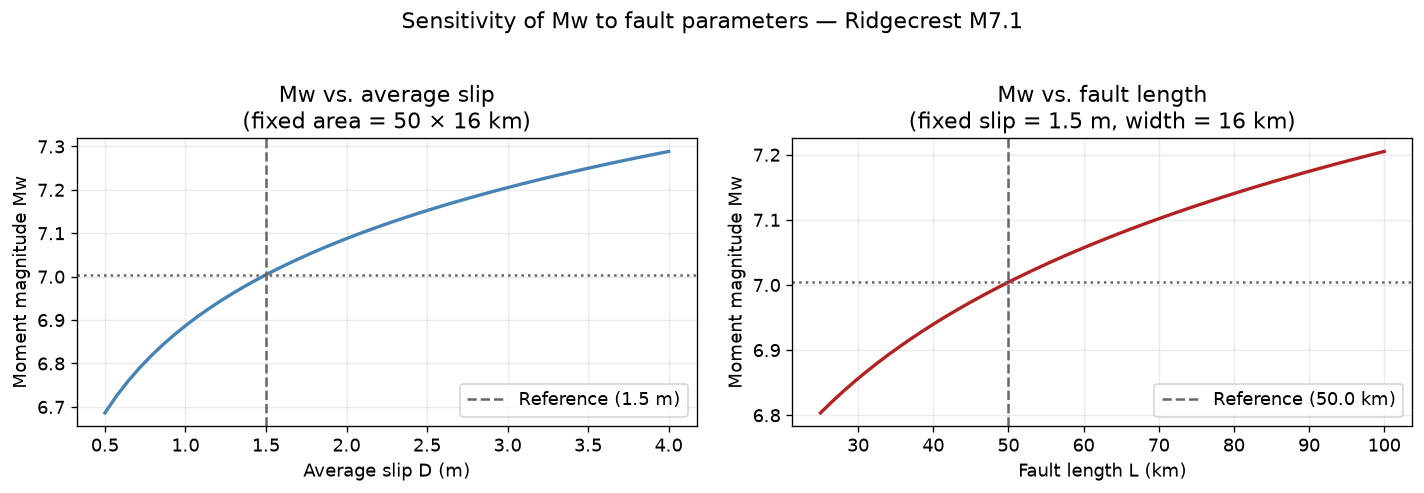

In [7]:
# Sensitivity exploration
# How sensitive is Mw to each fault parameter?

# Reference values
mu_ref     = 30.0
length_ref = 50.0
width_ref  = 16.0
slip_ref   = 1.5
_, Mw_ref  = compute_moment(mu_ref, length_ref, width_ref, slip_ref)

# Range of slip values to explore
slip_range   = np.linspace(0.5, 4.0, 50)
length_range = np.linspace(25, 100, 50)

Mw_slip   = [compute_moment(mu_ref, length_ref, width_ref, s)[1] for s in slip_range]
Mw_length = [compute_moment(mu_ref, L, width_ref, slip_ref)[1] for L in length_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(slip_range, Mw_slip, color="steelblue", lw=2)
axes[0].axvline(slip_ref, color="0.4", ls="--", label=f"Reference ({slip_ref} m)")
axes[0].axhline(Mw_ref, color="0.4", ls=":")
axes[0].set_xlabel("Average slip D (m)")
axes[0].set_ylabel("Moment magnitude Mw")
axes[0].set_title("Mw vs. average slip\n(fixed area = 50 × 16 km)")
axes[0].legend()

axes[1].plot(length_range, Mw_length, color="firebrick", lw=2)
axes[1].axvline(length_ref, color="0.4", ls="--", label=f"Reference ({length_ref} km)")
axes[1].axhline(Mw_ref, color="0.4", ls=":")
axes[1].set_xlabel("Fault length L (km)")
axes[1].set_ylabel("Moment magnitude Mw")
axes[1].set_title("Mw vs. fault length\n(fixed slip = 1.5 m, width = 16 km)")
axes[1].legend()

plt.suptitle("Sensitivity of Mw to fault parameters — Ridgecrest M7.1", y=1.02)
plt.tight_layout()
plt.show()


> **Interpret the moment calculation:**
> 1. How well does the uniform-slip estimate agree with the catalog Mw = 7.1? What does the discrepancy tell you about the limitations of a uniform slip model?
> 2. From the sensitivity plots: if slip doubles from 1.5 m to 3.0 m (keeping area fixed), by how much does Mw increase? If fault length doubles (keeping slip and width fixed), by how much does Mw increase?
> 3. M₀ scales linearly with μ, D, and A — but Mw is logarithmic. If you had a 10% uncertainty in average slip, what is the resulting uncertainty in Mw?
> 4. In geodetic inversions (Week 4), we solve for the slip distribution D across the fault from surface deformation. If we know D and A from geodesy, we can compute M₀ directly without any seismic data. Why might the seismically-determined and geodetically-determined M₀ values differ slightly?


---
## Part IV: First motions and focal mechanisms

In lecture we saw that P-wave first motions — whether the ground initially moves up (compression) or down (dilation) — constrain earthquake fault geometry. In this part you will:

1. Compute P-wave takeoff angles from station distances and source depth
2. Plot polarity observations on a lower-hemisphere focal sphere
3. Use interactive sliders to fit a focal mechanism to the observations
4. Interpret the result in terms of Ridgecrest fault geometry

We use pre-compiled first-motion polarities from CI network stations that recorded the Ridgecrest M7.1. The takeoff angle for each station ray is approximated from flat-Earth geometry:

$$
\theta_t = \arctan\left(\frac{\Delta}{h}\right)
$$

where $\Delta$ is the horizontal source–receiver distance in km and $h$ is the earthquake depth in km. This assumes straight-ray propagation in a homogeneous medium — a reasonable approximation for local distances.


In [ ]:
import pandas as pd

# M7.1 source depth
source_depth_km = 8.0

# Pre-compiled P-wave first motion observations from CI network stations
# Polarities: +1 = compressional (upward first motion), -1 = dilatational (downward)
# Azimuths and distances are from the M7.1 epicenter (35.770N, 117.599W)
stations = pd.DataFrame({
    "station":      ["CCC",  "SRT",  "MPM",  "MLAC", "BFS",  "GSC",  "LRL",
                     "NEE2", "ISA",  "BLA2", "MMLC", "HROO", "PAS",  "PFO",
                     "BAR",  "SBC",  "BKS",  "MHC",  "ORV",  "WDC"],
    "azimuth":      [190,    175,    295,    320,    210,    150,    135,
                     80,     255,    100,    355,    25,     208,    183,
                     215,    225,    330,    318,    340,    348],
    "distance_km": [ 22,     50,     38,     55,     65,     95,     88,
                     72,     130,    68,     50,     55,     240,    210,
                     195,    185,    395,    370,    420,    430],
    "polarity":     [+1,     +1,     -1,     -1,     +1,     +1,     +1,
                     -1,     -1,     -1,     -1,     +1,     +1,     +1,
                     +1,     -1,     -1,     -1,     -1,     -1],
})

# ── Task: compute takeoff angles ─────────────────────────────────────────────
# Fill in the formula below using arctan and the source depth.
# Hint: np.degrees(np.arctan2(a, b)) returns the angle in degrees.

stations["takeoff_angle"] =   # YOUR CODE HERE

print(f"Source depth: {source_depth_km} km")
print(f"\nStations and computed takeoff angles:")
display(stations)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from obspy.imaging.beachball import beach
from ipywidgets import interact, IntSlider

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


def focal_projection(takeoff_deg, azimuth_deg):
    """
    Equal-area (Lambert) lower-hemisphere projection.

    Parameters
    ----------
    takeoff_deg : float
        Takeoff angle in degrees from vertical (0 = straight up).
    azimuth_deg : float
        Station azimuth in degrees clockwise from north.

    Returns
    -------
    x, y : float
        Projected coordinates on the unit focal sphere.
    """
    toa = np.radians(takeoff_deg)
    az  = np.radians(azimuth_deg)
    r   = np.sqrt(2) * np.sin(toa / 2)
    return r * np.sin(az), r * np.cos(az)


def plot_focal_mechanism(strike=322, dip=85, rake=180):
    """
    Plot polarity observations on the focal sphere with an ObsPy beachball overlay.
    Adjust the sliders to find the mechanism that best fits the observations.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw the beachball using ObsPy
    b = beach(
        [strike, dip, rake],
        xy=(0, 0),
        width=2,
        linewidth=1.5,
        facecolor="steelblue",
        edgecolor="k",
        alpha=0.5,
    )
    ax.add_collection(b)

    # Plot polarity observations
    for _, row in stations.iterrows():
        x, y = focal_projection(row["takeoff_angle"], row["azimuth"])
        if row["polarity"] == 1:
            ax.plot(x, y, "ko", markersize=8, zorder=5)
        else:
            ax.plot(x, y, "wo", markersize=8, markeredgecolor="k",
                    markeredgewidth=1.5, zorder=5)
        ax.text(x + 0.03, y + 0.03, row["station"], fontsize=6.5,
                color="0.4", zorder=6)

    # Cardinal labels
    for label, x, y in [("N", 0, 1.1), ("S", 0, -1.1),
                         ("E", 1.1, 0), ("W", -1.1, 0)]:
        ax.text(x, y, label, ha="center", va="center",
                fontsize=12, fontweight="bold")

    # Legend
    ax.plot([], [], "ko", markersize=8, label="Compression (up)")
    ax.plot([], [], "wo", markersize=8, markeredgecolor="k",
            markeredgewidth=1.5, label="Dilation (down)")
    ax.legend(loc="lower right", fontsize=9)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"Strike = {strike}°   Dip = {dip}°   Rake = {rake}°\n"
        "Ridgecrest M7.1 — adjust sliders to fit polarities",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


interact(
    plot_focal_mechanism,
    strike=IntSlider(min=0,    max=360, step=1, value=322, description="Strike"),
    dip   =IntSlider(min=0,    max=90,  step=1, value=85,  description="Dip"),
    rake  =IntSlider(min=-180, max=180, step=1, value=180, description="Rake"),
)


**Tasks:**

1. Before touching the sliders, look at the polarity observations on the focal sphere. Describe the overall pattern — where are the compressional observations clustered, and where are the dilatational ones? What fault type does this pattern suggest?

2. Use the sliders to find the strike, dip, and rake that best fit all the polarity observations (all filled circles fall in shaded quadrants, all open circles in white quadrants). Record your preferred solution:

| Parameter | Your estimate | Published value |
|-----------|--------------|----------------|
| Strike    |              | 322°           |
| Dip       |              | 85°            |
| Rake      |              | 180°           |

3. The two nodal planes are orthogonal — the auxiliary plane to a 322°/85°/180° mechanism has strike ≈ 52°, dip ≈ 90°. Which plane is the actual fault? What additional evidence from the Ridgecrest sequence would help you decide?

4. A rake of 180° means right-lateral strike-slip. Is this consistent with the static GNSS offsets you measured in Part I? Explain.

5. The M6.4 foreshock two days earlier had a mechanism consistent with left-lateral slip on a NE-striking plane (roughly the auxiliary plane of the M7.1). How can two conjugate faults slip in opposite senses under the same regional stress field?


---
## Synthesis

> **In a short paragraph for each question, integrate what you have learned across all four parts of this lab.**
>
> 1. **Static vs. dynamic:** In Part I you measured a static offset of roughly ___ mm to the east at station P595. In Part IV you determined that the fault is NW-striking and right-lateral. Are these consistent? A right-lateral NW-striking fault should produce displacement in which direction on the east side of the fault? Does your GNSS observation agree?
>
> 2. **Complementarity of datasets:** Complete this table based on your observations:
>
> | Dataset | What it tells you about Ridgecrest M7.1 | What it cannot tell you |
> |---------|----------------------------------------|-------------------------|
> | High-rate GNSS | | |
> | Broadband seismograms | | |
> | Seismic moment calculation | | |
> | Focal mechanism | | |
>
> 3. **Looking ahead:** In Week 4 we will use Green's functions to invert geodetic data for fault slip. Given what you now know about the Ridgecrest fault geometry (strike, dip, rake from the focal mechanism) and fault dimensions and slip (from Part III), describe in plain language what a geodetic inversion would be doing. What are the knowns, what are the unknowns, and what observations constrain them?


---
## Summary

- High-rate GNSS records both **static** (permanent coseismic offset) and **dynamic** (transient wave passage) deformation in a single time series. Static offsets decay with distance; dynamic wave amplitudes also decay but the signal is detectable much farther from the source.
- **P waves** arrive before **S waves** at every station. The S–P time interval increases with epicentral distance and can be used to estimate source distance. Waveform character — dominant frequency, amplitude, pulse shape — changes systematically with distance due to geometric spreading and attenuation.
- **Scalar seismic moment** $M_0 = \mu D A$ directly connects measurable fault properties to earthquake size. **Moment magnitude** $M_w$ is logarithmic in $M_0$ and does not saturate. A factor-of-two change in slip produces a $\sim$0.2 unit change in $M_w$.
- **P-wave first motions** (up = compressional, down = dilatational) constrain the fault geometry. Plotting polarities on the focal sphere and finding two nodal planes gives the **focal mechanism** — strike, dip, and rake — in the same parameterization used for geodetic fault models.
- The **fault plane ambiguity** means seismology alone cannot identify which of the two nodal planes is the actual fault. Aftershock locations, surface rupture mapping, or geodetic surface deformation patterns resolve the ambiguity.
- **Green's functions** are the mathematical bridge between earthquake sources and observed seismograms, and between geodetic observations and fault slip models. The same framework underlies both seismic waveform modeling and the geodetic inversions we will develop in Week 4.

---
**References**

- Liu, C., et al. (2019). Fault geometry and slip distribution of the 2019 Ridgecrest earthquake sequence from joint inversion of strong motion, GPS, and InSAR data. *Geophysical Research Letters*, 46, 18. https://doi.org/10.1029/2019GL084949
- Atterholt, J., et al. (2025). Focal mechanisms of the 2019 Ridgecrest aftershock sequence. *Seismological Research Letters*.
- IRIS/EarthScope Consortium: https://ds.iris.edu
- UNAVCO/EarthScope high-rate GNSS: https://www.unavco.org
- Global CMT Catalog: https://www.globalcmt.org
- Shearer, P. M. (2009). *Introduction to Seismology*, 2nd ed. Cambridge University Press.
